**Importing Dependencies**

In [23]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from xgboost import XGBRegressor

**Data Collection and Preprocessing**

In [2]:
# Loading Daatset into Pandas Dataframe
calories_dataset = pd.read_csv('/content/calories.csv')

In [3]:
# Printing 5 rows of Dataset:
calories_dataset.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
# Uploading [Excerics] Dataset:
excercise_dataset = pd.read_csv('/content/exercise.csv')

In [5]:
excercise_dataset.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


**Combining two DataFrames**

In [6]:
calories_data = pd.concat([excercise_dataset, calories_dataset['Calories']], axis=1)

In [7]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [8]:
# Number of Rows and Columns:
calories_data.shape

(15000, 9)

In [10]:
# Getting Information of Dataset:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [11]:
# Checkig for Missing Values:
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


**Data Analysis**

In [13]:
# Statistical Measures of Dataset:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Label Encoding
1. Categorical to Numerical

In [24]:
encoder = LabelEncoder()

In [25]:
calories_data['Gender'] = encoder.fit_transform(calories_data['Gender'])

In [30]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0


**Data Visualization**

In [14]:
sns.set()

<Axes: xlabel='count', ylabel='Gender'>

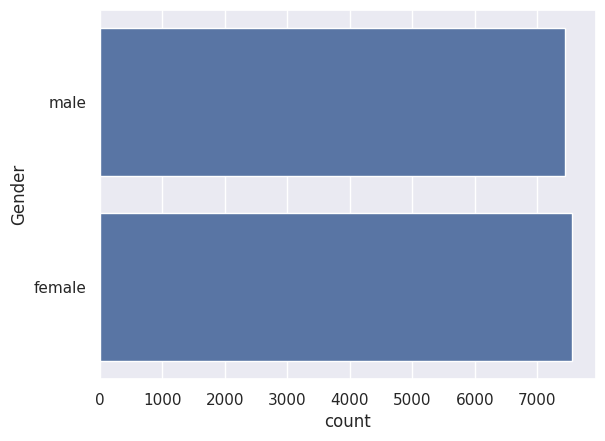

In [15]:
# Count Plot of Gender Column:
sns.countplot(calories_data['Gender'])

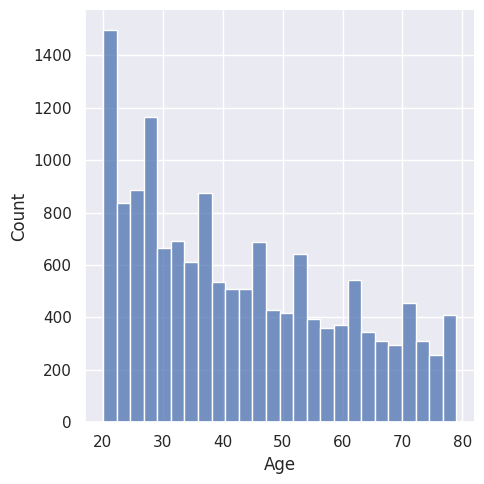

In [17]:
# Finding the Distribution of Age column:
sns.displot(calories_data['Age'])

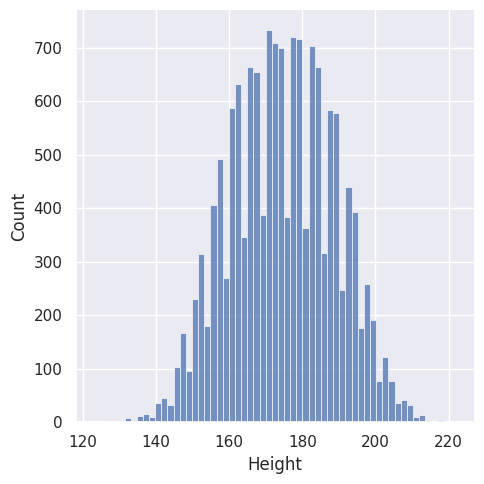

In [18]:
# Finding the Distribution of 'Height' column:
sns.displot(calories_data['Height'])

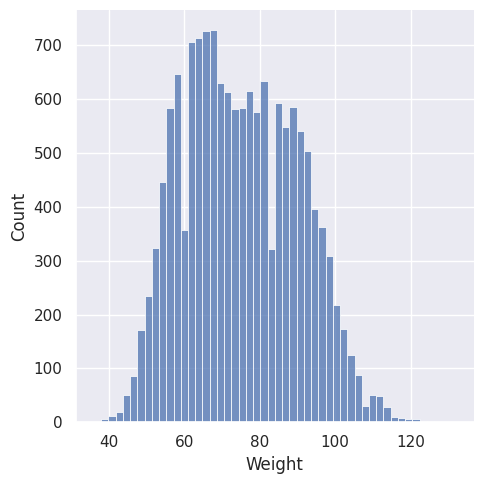

In [19]:
# Finding the Distribution of 'Weight' column:
sns.displot(calories_data['Weight'])

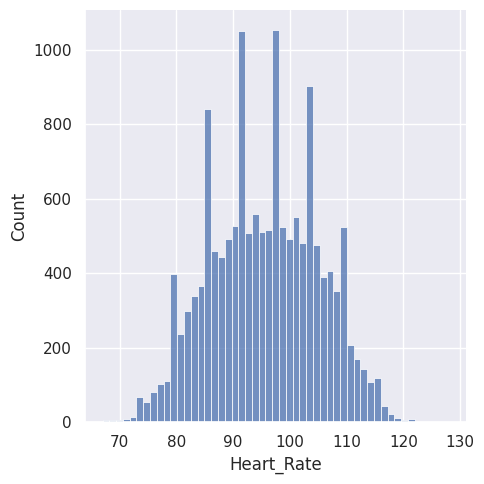

In [20]:
# Finding the Distribution of 'Heart_Rate' column:
sns.displot(calories_data['Heart_Rate'])

**Correlation**

1. Positive Correlation
2. Negative Correlation

In [26]:
correlation = calories_data.corr()

<Axes: >

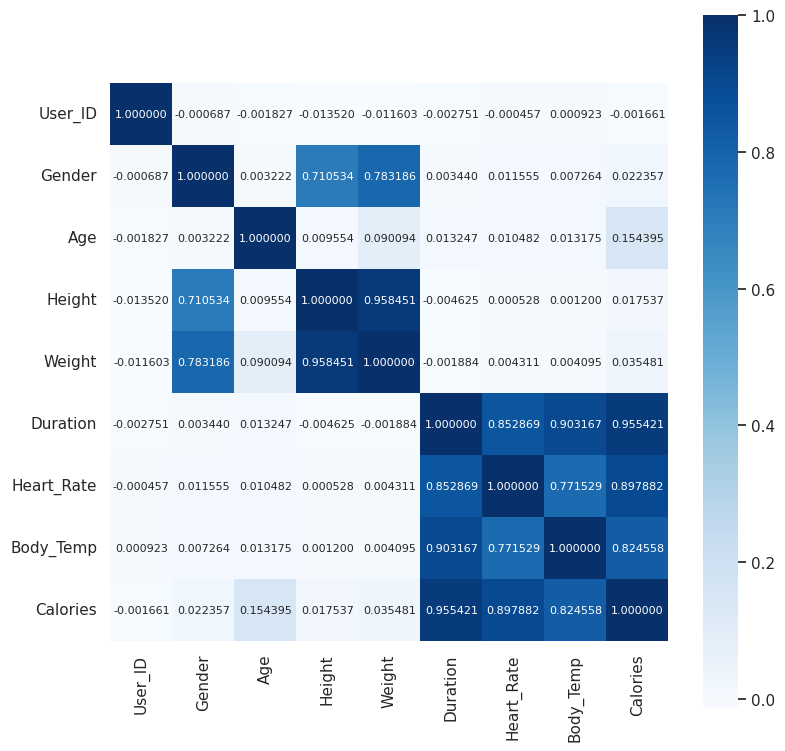

In [29]:
# Constructing Heatmap to visualize the Correlation
plt.figure(figsize=(9,9))
sns.heatmap(correlation, cbar=True, square= True , fmt='1f', annot=True , annot_kws={'size':8}, cmap='Blues')

**Splitting Features and Targets**

In [31]:
X = calories_data.drop(columns= ['User_ID','Calories'], axis=1)
Y = calories_data['Calories']

In [32]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           1   68   190.0    94.0      29.0       105.0       40.8
1           0   20   166.0    60.0      14.0        94.0       40.3
2           1   69   179.0    79.0       5.0        88.0       38.7
3           0   34   179.0    71.0      13.0       100.0       40.5
4           0   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       0   20   193.0    86.0      11.0        92.0       40.4
14996       0   27   165.0    65.0       6.0        85.0       39.2
14997       0   43   159.0    58.0      16.0        90.0       40.1
14998       1   78   193.0    97.0       2.0        84.0       38.3
14999       1   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [33]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


**Splitting Data into Training and Test Data**

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [36]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


**Model Training**

**XGBoost Regressor**

In [39]:
model = XGBRegressor()

In [40]:
# Fitting Data to Model:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

**Model Evaluation**

In [41]:
# Predicting model score with Training data
training_data_prediction = model.predict(X_train)
print("Training Data Prediction: ", training_data_prediction)

Training Data Prediction:  [ 11.680271  36.71814   31.747328 ... 108.05978  179.23735   44.236874]


In [42]:
# Predicting model score with Testing Data:
test_data_prediction = model.predict(X_test)
print("Testing Data Prediction: ", test_data_prediction)

Testing Data Prediction:  [125.58828  222.11377   38.725952 ... 144.3179    23.425894  90.100494]


Mean Absolute Error

In [43]:
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
print("Mean Absolute Error: ", mae)

Mean Absolute Error:  1.4833678883314132


In [44]:
mae_training  = metrics.mean_absolute_error(Y_train, training_data_prediction)
print("Mean Absolute Error: ", mae_training)

Mean Absolute Error:  0.9322033420062313


**Predictive System**

In [46]:
# Example input (replace with your own values)
# Gender, Age, Height, Weight, Duration, Heart_Rate, Body_Temp
input_data = (0,20,166.0,60.0,14.0,94.0,40.3)

# Convert input into numpy array
input_data_into_numpy_array = np.asarray(input_data)

# Reshape for a single prediction
input_data_reshaped = input_data_into_numpy_array.reshape(1, -1)

# Predict calories
prediction = model.predict(input_data_reshaped)

print("Predicted Calories Burnt:", round(prediction[0], 2))

Predicted Calories Burnt: 65.85
